Using device: cuda
Pure Mean Curvature Flow (GPU Accelerated) - FIXED
Device: cuda
Points: 3000, KNN: 20
Initial area: 6.7225
Initial density std/mean: 0.164129

Starting pure MCF evolution...
(Surface should SHRINK - area should DECREASE)
  [Debug] Normals pointing outward: 50.0%
  [Debug] After fix, all normals point outward: 100.0%
  [Debug] Mean curvature range: [-2.9759, -0.8603]
  [Debug] Mean curvature (should be positive for convex): -1.5457
  Step 0: t = 0.001680, area = 6.6468, density = 0.1598, max|v| = 2.9759, radial_v = -0.918151 (should be NEGATIVE)
  Step 100: t = 0.135399, area = 1.6073, density = 0.7257, max|v| = 9.0451, radial_v = -1.558720 (should be NEGATIVE)
  Step 200: t = 0.157450, area = 0.8272, density = 1.0230, max|v| = 89.4244, radial_v = -2.373432 (should be NEGATIVE)
  Step 300: t = 0.164201, area = 0.5860, density = 1.0642, max|v| = 216.9761, radial_v = -2.515078 (should be NEGATIVE)


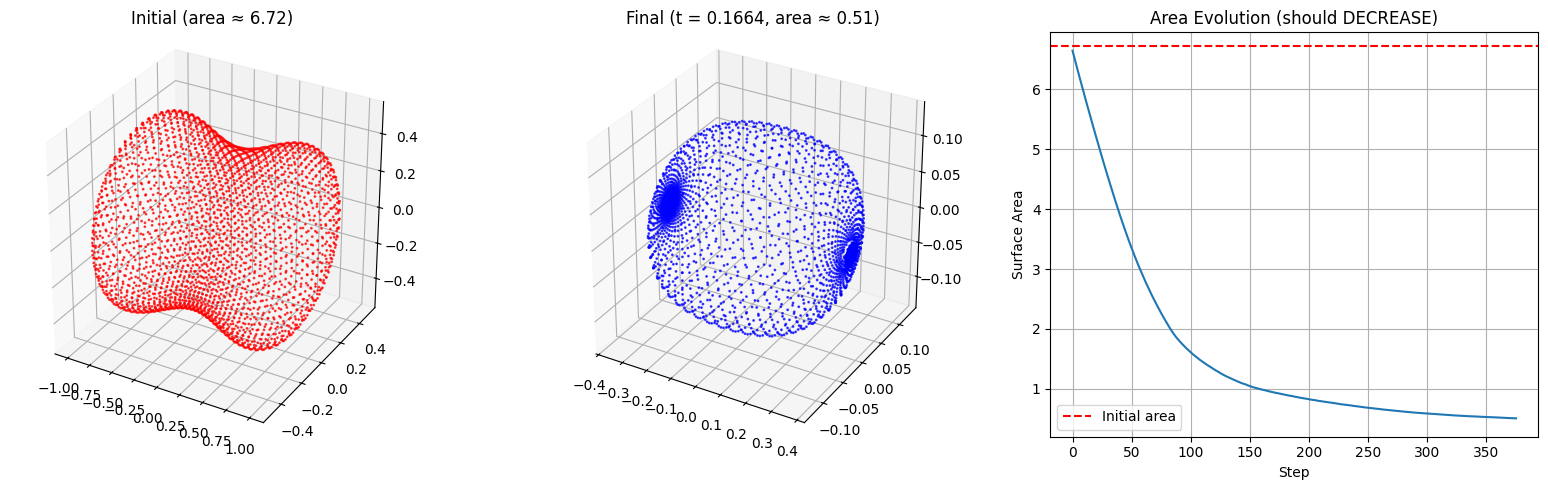


Final: t = 0.166440, area = 0.5071, density = 1.213178
Area change: -6.1397 (DECREASE ✓)


In [52]:
import numpy as np
import torch
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 3000
K_NEIGHBORS = 20  # 增大到20以获得更稳定的曲率估计
DT = 0.05
MAX_STEPS_MCF = 376

# GPU 设置
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ============================================
# 1. 初始椭球面
# ============================================
def generate_initial_ellipsoid(n_points):
    indices = torch.arange(n_points, device=DEVICE)
    phi = torch.arccos(1 - 2 * (indices + 0.5) / n_points)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    r_factor = 3/5 * torch.cos(phi)**2 + 2/5
    x = torch.cos(phi)
    y = r_factor * torch.cos(theta) * torch.sin(phi)
    z = r_factor * torch.sin(theta) * torch.sin(phi)
    return torch.stack([x, y, z], dim=1)

# ============================================
# 2. 高效 KNN 搜索（GPU 加速）
# ============================================
def knn_search(X, k, exclude_self=True):
    """批量 KNN 搜索，使用 GPU 矩阵运算"""
    dist_matrix = torch.cdist(X, X, p=2)
    
    if exclude_self:
        dist_matrix.fill_diagonal_(float('inf'))
        _, indices = torch.topk(dist_matrix, k, largest=False, dim=1)
    else:
        _, indices = torch.topk(dist_matrix, k, largest=False, dim=1)
    
    return indices

# ============================================
# 3. 法向量（PCA 版本，确保指向外部）
# ============================================
def compute_normals_pca(X):
    """使用 GPU 批量计算 PCA 法向量，并确保指向外部"""
    N_pts = len(X)
    indices = knn_search(X, K_NEIGHBORS)
    neighbors = X[indices]  # (N, K, 3)
    
    # 批量计算质心
    centroid = neighbors.mean(dim=1, keepdim=True)  # (N, 1, 3)
    centered = neighbors - centroid  # (N, K, 3)
    
    # 批量计算协方差矩阵
    C = torch.bmm(centered.transpose(1, 2), centered) / K_NEIGHBORS  # (N, 3, 3)
    
    # 批量特征值分解
    eigenvalues, eigenvectors = torch.linalg.eigh(C)  # (N, 3), (N, 3, 3)
    
    # 最小特征值对应的特征向量（第一个）
    normals = eigenvectors[:, :, 0]  # (N, 3)
    
    # ★★★ 关键修复：确保法向量一致指向外部 ★★★
    # 计算曲面的质心（闭合曲面的近似中心）
    surface_centroid = X.mean(dim=0, keepdim=True)  # (1, 3)
    
    # 从质心指向曲面点的向量（指向外部）
    outward_direction = X - surface_centroid  # (N, 3)
    
    # 检查法向量是否与向外方向一致
    dot_product = (normals * outward_direction).sum(dim=1)  # (N,)
    
    # 如果点积为负，说明法向量指向内部，翻转它
    normals[dot_product < 0] = -normals[dot_product < 0]
    
    # 归一化
    normals = torch.nn.functional.normalize(normals, dim=1)
    
    # 调试输出（仅第一步）
    if not hasattr(compute_normals_pca, 'debug_printed'):
        compute_normals_pca.debug_printed = True
        pos_ratio = (dot_product > 0).float().mean().item()
        print(f"  [Debug] Normals pointing outward: {pos_ratio*100:.1f}%")
        print(f"  [Debug] After fix, all normals point outward: "
              f"{((normals * outward_direction).sum(dim=1) > 0).float().mean().item()*100:.1f}%")
    
    return normals

# ============================================
# 4. 曲率估计（GPU 加速）
# ============================================
def compute_mean_curvature_fitted(X, normals):
    """使用 GPU 批量计算曲率，确保正确的符号"""
    N_pts = len(X)
    indices = knn_search(X, K_NEIGHBORS)
    neighbors = X[indices]  # (N, K, 3)
    
    # 批量计算局部坐标
    centered = neighbors - X.unsqueeze(1)  # (N, K, 3)
    n = normals  # (N, 3)
    
    # 构建切平面基向量
    e1 = torch.zeros_like(n)
    mask = torch.abs(n[:, 0]) < 0.9
    e1[mask, 0] = -n[mask, 1]
    e1[mask, 1] = n[mask, 0]
    e1[~mask, 1] = -n[~mask, 2]
    e1[~mask, 2] = n[~mask, 1]
    e1 = torch.nn.functional.normalize(e1, dim=1)
    e2 = torch.cross(n, e1, dim=1)
    
    # 批量投影到切平面
    u = (centered * e1.unsqueeze(1)).sum(dim=2)  # (N, K)
    v = (centered * e2.unsqueeze(1)).sum(dim=2)  # (N, K)
    w = (centered * n.unsqueeze(1)).sum(dim=2)  # (N, K)
    
    # 批量最小二乘拟合
    A = torch.stack([u**2, u*v, v**2], dim=2)  # (N, K, 3)
    
    # 使用 torch.linalg.lstsq 批量求解
    try:
        solution = torch.linalg.lstsq(A, w.unsqueeze(2))
        coeffs = solution.solution.squeeze(2)
        H = coeffs[:, 0] + coeffs[:, 2]
    except:
        # 如果批量失败，逐点处理
        H = torch.zeros(N_pts, device=DEVICE)
        for i in range(N_pts):
            try:
                coeffs_i = torch.linalg.lstsq(A[i:i+1], w[i:i+1].unsqueeze(2)).solution
                H[i] = coeffs_i[0, 0] + coeffs_i[0, 2]
            except:
                H[i] = 0
    
    # 调试输出
    if not hasattr(compute_mean_curvature_fitted, 'debug_printed'):
        compute_mean_curvature_fitted.debug_printed = True
        print(f"  [Debug] Mean curvature range: [{H.min().item():.4f}, {H.max().item():.4f}]")
        print(f"  [Debug] Mean curvature (should be positive for convex): {H.mean().item():.4f}")
    
    return H

# ============================================
# 5. 密度估计（GPU 加速）
# ============================================
def estimate_density_std(X):
    N_pts = len(X)
    k = 20
    indices = knn_search(X, k, exclude_self=True)
    neighbors = X[indices]
    centroid = neighbors.mean(dim=1, keepdim=True)
    dist_to_centroid = torch.norm(neighbors - centroid, dim=2)
    local_area = np.pi * dist_to_centroid.mean(dim=1)**2
    local_density = k / (local_area + 1e-12)
    return (torch.std(local_density) / torch.mean(local_density)).item()

# ============================================
# 6. 纯 MCF 演化（修复后的版本）
# ============================================
def pure_mcf_evolution(X, dt, max_steps):
    """
    纯平均曲率流：只有法向速度 v = -H * n
    确保法向量指向外部，使得 v 指向内部（收缩）
    """
    t_current = 0.0
    area_history = []
    density_history = []
    
    print("\nStarting pure MCF evolution...")
    print("(Surface should SHRINK - area should DECREASE)")
    
    for step in range(max_steps):
        # 计算法向量（确保指向外部）
        normals = compute_normals_pca(X)
        
        # 计算平均曲率（对于凸曲面应该是正的）
        H = compute_mean_curvature_fitted(X, normals)
        
        # ★★★ 法向速度：v = -H * n ★★★
        # H > 0（凸曲面），n指向外部 → v指向内部（收缩）✓
        vn = H.unsqueeze(1) * normals
        
        # 计算最大速度以调整时间步长
        v_norm = torch.norm(vn, dim=1).max().item()
        
        if v_norm < 1e-8:
            print(f"  Converged at step {step}, max|v| = {v_norm:.2e}")
            break
        
        # 自适应时间步长（更保守的步长限制）
        dt_effective = min(dt, 0.005 / (v_norm + 1e-8))
        
        # 更新顶点位置
        X = X + dt_effective * vn
        t_current += dt_effective
        
        # 计算表面积（转到 CPU）
        try:
            X_cpu = X.cpu().numpy()
            hull = ConvexHull(X_cpu)
            area = hull.area
        except:
            area = 0
        area_history.append(area)
        
        if step % 100 == 0:
            density = estimate_density_std(X)
            density_history.append(density)
            
            # 检查速度方向（调试）
            radial_direction = X - X.mean(dim=0, keepdim=True)
            radial_velocity = (vn * radial_direction).sum(dim=1).mean().item()
            
            print(f"  Step {step}: t = {t_current:.6f}, area = {area:.4f}, "
                  f"density = {density:.4f}, max|v| = {v_norm:.4f}, "
                  f"radial_v = {radial_velocity:.6f} (should be NEGATIVE)")
    
    return X, t_current, area_history, density_history

# ============================================
# 7. 主程序
# ============================================
def main():
    print("=" * 60)
    print("Pure Mean Curvature Flow (GPU Accelerated) - FIXED")
    print(f"Device: {DEVICE}")
    print(f"Points: {N}, KNN: {K_NEIGHBORS}")
    print("=" * 60)
    
    # 生成初始点云（在 GPU 上）
    X = generate_initial_ellipsoid(N)
    X_initial = X.clone()
    
    # 计算初始面积
    try:
        X_initial_cpu = X_initial.cpu().numpy()
        hull_initial = ConvexHull(X_initial_cpu)
        area_initial = hull_initial.area
        print(f"Initial area: {area_initial:.4f}")
    except:
        area_initial = None
    
    density_initial = estimate_density_std(X)
    print(f"Initial density std/mean: {density_initial:.6f}")
    
    # 纯 MCF 演化
    X_final, t_final, area_history, density_history = pure_mcf_evolution(
        X, DT, MAX_STEPS_MCF
    )
    
    # 可视化（需要转到 CPU）
    X_initial_cpu = X_initial.cpu().numpy()
    X_final_cpu = X_final.cpu().numpy()
    
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial_cpu[:, 0], X_initial_cpu[:, 1], X_initial_cpu[:, 2], 
                s=1, c='red', alpha=0.7)
    ax1.set_title(f'Initial (area ≈ {area_initial:.2f})')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_final_cpu[:, 0], X_final_cpu[:, 1], X_final_cpu[:, 2], 
                s=1, c='blue', alpha=0.7)
    ax2.set_title(f'Final (t = {t_final:.4f}, area ≈ {area_history[-1]:.2f})')
    ax2.set_box_aspect([1, 1, 1])
    
    ax3 = fig.add_subplot(133)
    ax3.plot(area_history)
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Surface Area')
    ax3.set_title('Area Evolution (should DECREASE)')
    ax3.grid(True)
    
    # 添加初始面积参考线
    if area_initial:
        ax3.axhline(y=area_initial, color='r', linestyle='--', label='Initial area')
        ax3.legend()
    
    plt.tight_layout()
    plt.show()
    
    final_density = estimate_density_std(X_final)
    print(f"\nFinal: t = {t_final:.6f}, area = {area_history[-1]:.4f}, "
          f"density = {final_density:.6f}")
    
    # 验证面积确实减小了
    if len(area_history) > 0:
        area_change = area_history[-1] - area_history[0]
        print(f"Area change: {area_change:.4f} "
              f"({'DECREASE ✓' if area_change < 0 else 'INCREASE ✗'})")
    
    return X_final, area_history, density_history

if __name__ == "__main__":
    X_final, area_hist, density_hist = main()

In [ ]:
import numpy as np
import torch
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 3000
MAX_DEG = 3
N_LOCAL = 50
EPSILON = 0.5
ALPHA = 1.0
DT = 0.05
MAX_STEPS_STATIC = 500
MAX_STEPS_MCF = 300
UNIFORMIZE_EVERY = 1000
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6
K_NEIGHBORS = 20

# GPU 设置
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ============================================
# 1. 初始椭球面
# ============================================
def generate_initial_ellipsoid(n_points):
    indices = torch.arange(n_points, device=DEVICE)
    phi = torch.arccos(1 - 2 * (indices + 0.5) / n_points)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    r_factor = 3/5 * torch.cos(phi)**2 + 2/5
    x = torch.cos(phi)
    y = r_factor * torch.cos(theta) * torch.sin(phi)
    z = r_factor * torch.sin(theta) * torch.sin(phi)
    return torch.stack([x, y, z], dim=1)

# ============================================
# 2. 高效 KNN 搜索（GPU 加速）
# ============================================
def knn_search(X, k, exclude_self=True):
    dist_matrix = torch.cdist(X, X, p=2)
    if exclude_self:
        dist_matrix.fill_diagonal_(float('inf'))
        _, indices = torch.topk(dist_matrix, k, largest=False, dim=1)
    else:
        _, indices = torch.topk(dist_matrix, k, largest=False, dim=1)
    return indices

# ============================================
# 3. 法向量
# ============================================
def compute_normals_pca(X):
    N_pts = len(X)
    indices = knn_search(X, K_NEIGHBORS)
    neighbors = X[indices]
    centroid = neighbors.mean(dim=1, keepdim=True)
    centered = neighbors - centroid
    C = torch.bmm(centered.transpose(1, 2), centered) / K_NEIGHBORS
    eigenvalues, eigenvectors = torch.linalg.eigh(C)
    normals = eigenvectors[:, :, 0]
    dot_product = (normals * X).sum(dim=1)
    normals[dot_product < 0] = -normals[dot_product < 0]
    return torch.nn.functional.normalize(normals, dim=1)

def compute_normals_analytical(X):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    phi = torch.arccos(torch.clamp(x, -1, 1))
    theta = torch.atan2(z, y + 1e-15)
    r = 3/5 * torch.cos(phi)**2 + 2/5
    dr = -6/5 * torch.cos(phi) * torch.sin(phi)
    
    dx_phi = -torch.sin(phi)
    dx_theta = torch.zeros_like(x)
    dy_phi = dr * torch.cos(theta) * torch.sin(phi) + r * torch.cos(theta) * torch.cos(phi)
    dy_theta = -r * torch.sin(theta) * torch.sin(phi)
    dz_phi = dr * torch.sin(theta) * torch.sin(phi) + r * torch.sin(theta) * torch.cos(phi)
    dz_theta = r * torch.cos(theta) * torch.sin(phi)
    
    t_phi = torch.stack([dx_phi, dy_phi, dz_phi], dim=1)
    t_theta = torch.stack([dx_theta, dy_theta, dz_theta], dim=1)
    normals = torch.cross(t_phi, t_theta, dim=1)
    normals = torch.nn.functional.normalize(normals, dim=1)
    
    dot_product = (normals * X).sum(dim=1)
    normals[dot_product < 0] = -normals[dot_product < 0]
    return normals

compute_normals_static = compute_normals_analytical
compute_normals_dynamic = compute_normals_pca

# ============================================
# 4. 曲率估计
# ============================================
def compute_mean_curvature_fitted(X, normals):
    N_pts = len(X)
    indices = knn_search(X, K_NEIGHBORS)
    neighbors = X[indices]
    centered = neighbors - X.unsqueeze(1)
    n = normals
    
    e1 = torch.zeros_like(n)
    mask = torch.abs(n[:, 0]) < 0.9
    e1[mask, 0] = -n[mask, 1]
    e1[mask, 1] = n[mask, 0]
    e1[~mask, 1] = -n[~mask, 2]
    e1[~mask, 2] = n[~mask, 1]
    e1 = torch.nn.functional.normalize(e1, dim=1)
    e2 = torch.cross(n, e1, dim=1)
    
    u = (centered * e1.unsqueeze(1)).sum(dim=2)
    v = (centered * e2.unsqueeze(1)).sum(dim=2)
    w = (centered * n.unsqueeze(1)).sum(dim=2)
    
    A = torch.stack([u**2, u*v, v**2], dim=2)
    
    try:
        solution = torch.linalg.lstsq(A, w.unsqueeze(2))
        coeffs = solution.solution.squeeze(2)
        H = coeffs[:, 0] + coeffs[:, 2]
    except:
        H = torch.zeros(N_pts, device=DEVICE)
        for i in range(N_pts):
            try:
                coeffs_i = torch.linalg.lstsq(A[i:i+1], w[i:i+1].unsqueeze(2)).solution
                H[i] = coeffs_i[0, 0] + coeffs_i[0, 2]
            except:
                H[i] = 0
    return H

# ============================================
# 5. 多项式基函数
# ============================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return torch.stack(vals_list, dim=1)

def polynomial_basis_gradients_3d(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = torch.zeros((N_pts, M_poly, 3), device=DEVICE)
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

def polynomial_basis_tangent_gradients(X, max_deg, normals):
    grads_3d = polynomial_basis_gradients_3d(X, max_deg)
    normal_proj = (grads_3d * normals.unsqueeze(1)).sum(dim=2)
    return grads_3d - normal_proj.unsqueeze(2) * normals.unsqueeze(1)

# ============================================
# 6. Wendland C2 局部基函数
# ============================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = torch.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = torch.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X.unsqueeze(1) - centers.unsqueeze(0)
    dist = torch.norm(diff, dim=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients_3d(X, centers, epsilon):
    diff = X.unsqueeze(1) - centers.unsqueeze(0)
    dist = torch.norm(diff, dim=2)
    dist_safe = torch.where(dist < 1e-12, torch.tensor(1e-12, device=DEVICE), dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr.unsqueeze(2) * diff / dist_safe.unsqueeze(2)
    return grad

# ============================================
# 7. 混合基函数
# ============================================
def mixed_basis_values_and_tangent_gradients(X, max_deg, local_centers, epsilon, normals):
    poly_vals = polynomial_basis_values(X, max_deg)
    poly_grads_3d = polynomial_basis_gradients_3d(X, max_deg)
    poly_normal_proj = (poly_grads_3d * normals.unsqueeze(1)).sum(dim=2)
    poly_grads_tangent = poly_grads_3d - poly_normal_proj.unsqueeze(2) * normals.unsqueeze(1)
    
    local_vals = local_basis_values(X, local_centers, epsilon)
    local_grads_3d = local_basis_gradients_3d(X, local_centers, epsilon)
    local_normal_proj = (local_grads_3d * normals.unsqueeze(1)).sum(dim=2)
    local_grads_tangent = local_grads_3d - local_normal_proj.unsqueeze(2) * normals.unsqueeze(1)
    
    vals = torch.cat([poly_vals, local_vals], dim=1)
    grads = torch.cat([poly_grads_tangent, local_grads_tangent], dim=1)
    
    return vals, grads

# ============================================
# 8. 生成均匀基函数中心
# ============================================
def generate_uniform_centers(X, n_centers):
    X_cpu = X.cpu().numpy()
    candidates = X_cpu[np.random.choice(len(X_cpu), min(5000, len(X_cpu)), replace=False)]
    selected = [np.random.randint(len(candidates))]
    min_dist = np.full(len(candidates), np.inf)
    for _ in range(n_centers - 1):
        last = candidates[selected[-1]]
        dist_to_last = np.linalg.norm(candidates - last, axis=1)
        min_dist = np.minimum(min_dist, dist_to_last)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)
        min_dist[next_idx] = -1
    return torch.tensor(candidates[np.array(selected)], device=DEVICE, dtype=torch.float32)

# ============================================
# 9. 均匀参考值
# ============================================
def compute_uniform_reference_mixed(X, max_deg, local_centers, epsilon, normals_func):
    n_samples = min(20000, len(X))
    idx = torch.randperm(len(X), device=DEVICE)[:n_samples]
    X_ref = X[idx]
    normals_ref = normals_func(X_ref)
    
    indices = knn_search(X_ref, 20, exclude_self=True)
    neighbors = X_ref[indices]
    centroid = neighbors.mean(dim=1, keepdim=True)
    dist_to_centroid = torch.norm(neighbors - centroid, dim=2)
    areas = np.pi * dist_to_centroid.mean(dim=1)**2
    
    psi_sample, _ = mixed_basis_values_and_tangent_gradients(
        X_ref, max_deg, local_centers, epsilon, normals_ref
    )
    
    weights = areas / areas.sum()
    return (psi_sample * weights.unsqueeze(1)).sum(dim=0)

# ============================================
# 10. 密度估计
# ============================================
def estimate_density_std(X):
    N_pts = len(X)
    k = 20
    indices = knn_search(X, k, exclude_self=True)
    neighbors = X[indices]
    centroid = neighbors.mean(dim=1, keepdim=True)
    dist_to_centroid = torch.norm(neighbors - centroid, dim=2)
    local_area = np.pi * dist_to_centroid.mean(dim=1)**2
    local_density = k / (local_area + 1e-12)
    return (torch.std(local_density) / torch.mean(local_density)).item()

# ============================================
# 11. 静态均匀化
# ============================================
def static_uniformization(X, max_deg, local_centers, epsilon, alpha, dt, max_steps):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + len(local_centers)
    
    uniform_avg = compute_uniform_reference_mixed(
        X, max_deg, local_centers, epsilon, compute_normals_static
    )
    
    for step in range(max_steps):
        normals = compute_normals_static(X)
        psi, grads_tangent = mixed_basis_values_and_tangent_gradients(
            X, max_deg, local_centers, epsilon, normals
        )
        
        b_full = -alpha * (psi.mean(dim=0) - uniform_avg)
        
        support_counts = (torch.abs(psi) > SUPPORT_THRESHOLD).sum(dim=0)
        poly_valid = torch.ones(M_poly, dtype=torch.bool, device=DEVICE)
        local_valid = support_counts[M_poly:] >= MIN_SUPPORT
        valid_mask = torch.cat([poly_valid, local_valid])
        
        psi_valid = psi[:, valid_mask]
        grads_valid = grads_tangent[:, valid_mask, :]
        
        A_valid = (grads_valid @ grads_valid.transpose(1, 2)).mean(dim=0)
        b_valid = b_full[valid_mask]
        
        try:
            c_valid = torch.linalg.solve(A_valid, b_valid)
        except:
            c_valid = torch.linalg.lstsq(A_valid, b_valid.unsqueeze(1)).solution.squeeze(1)
        
        c = torch.zeros(M_total, device=DEVICE)
        c[valid_mask] = c_valid
        
        vT = (grads_tangent * c.unsqueeze(0).unsqueeze(2)).sum(dim=1)
        vT = vT - (vT * normals).sum(dim=1, keepdim=True) * normals
        
        v_norm = torch.norm(vT, dim=1).max().item()
        if v_norm < 1e-12:
            break
        
        dt_effective = min(dt, 0.01 / (v_norm + 1e-8))
        X = X + dt_effective * vT
        
        if step % 50 == 0:
            density = estimate_density_std(X)
            print(f"  Step {step}: density = {density:.6f}, v_max = {v_norm:.4f}")
    
    return X

# ============================================
# 12. MCF + 切向控制 + 法向量可视化
# ============================================
def dynamic_mcf_with_control(X, max_deg, dt, max_steps):
    M = polynomial_basis_values(torch.zeros((1, 3), device=DEVICE), max_deg).shape[1]
    
    t_current = 0.0
    area_history = []
    density_history = []
    normals_history = []  # 存储法向量用于可视化
    
    for step in range(max_steps):
        normals = compute_normals_dynamic(X)
        H = compute_mean_curvature_fitted(X, normals)
        vn = H.unsqueeze(1) * normals
        
        psi = polynomial_basis_values(X, max_deg)
        grads_tangent = polynomial_basis_tangent_gradients(X, max_deg, normals)
        
        # 法向速度散度
        eps = 1e-5
        e1 = torch.zeros_like(normals)
        mask = torch.abs(normals[:, 0]) < 0.9
        e1[mask, 0] = -normals[mask, 1]
        e1[mask, 1] = normals[mask, 0]
        e1[~mask, 1] = -normals[~mask, 2]
        e1[~mask, 2] = normals[~mask, 1]
        e1 = torch.nn.functional.normalize(e1, dim=1)
        e2 = torch.cross(normals, e1, dim=1)
        
        div_vn = torch.zeros(len(X), device=DEVICE)
        for e_vec in [e1, e2]:
            X_plus = X + eps * e_vec
            X_minus = X - eps * e_vec
            n_plus = compute_normals_dynamic(X_plus)
            n_minus = compute_normals_dynamic(X_minus)
            H_plus = compute_mean_curvature_fitted(X_plus, n_plus)
            H_minus = compute_mean_curvature_fitted(X_minus, n_minus)
            vn_plus = -H_plus.unsqueeze(1) * n_plus
            vn_minus = -H_minus.unsqueeze(1) * n_minus
            vn_dot_plus = (vn_plus * e_vec).sum(dim=1)
            vn_dot_minus = (vn_minus * e_vec).sum(dim=1)
            div_vn += (vn_dot_plus - vn_dot_minus) / (2 * eps)
        
        A = (grads_tangent @ grads_tangent.transpose(1, 2)).mean(dim=0)
        f_bar = div_vn.mean()
        psi_bar = psi.mean(dim=0)
        b_drive = (psi * div_vn.unsqueeze(1)).mean(dim=0) - psi_bar * f_bar
        
        try:
            c = torch.linalg.solve(A, b_drive)
        except:
            c = torch.linalg.lstsq(A, b_drive.unsqueeze(1)).solution.squeeze(1)
        
        vT = (grads_tangent * c.unsqueeze(0).unsqueeze(2)).sum(dim=1)
        #vT = vT - (vT * normals).sum(dim=1, keepdim=True) * normals
        
        v_total = vn - vT
        v_norm = torch.norm(v_total, dim=1).max().item()
        dt_effective = min(dt, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * v_total
        t_current += dt_effective
        
        try:
            X_cpu = X.cpu().numpy()
            hull = ConvexHull(X_cpu)
            area = hull.area
        except:
            area = 0
        area_history.append(area)
        
        # 存储法向量（每50步）
        if step % 50 == 0:
            normals_history.append({
                'step': step,
                't': t_current,
                'X': X.cpu().numpy().copy(),
                'normals': normals.cpu().numpy().copy()
            })
        
        if step % 100 == 0:
            density = estimate_density_std(X)
            density_history.append(density)
            max_vn = torch.norm(vn, dim=1).max().item()
            max_vT = torch.norm(vT, dim=1).max().item()
            print(f"  Step {step}: t = {t_current:.6f}, area = {area:.4f}, density = {density:.4f}, "
                  f"max|vn| = {max_vn:.4f}, max|vT| = {max_vT:.4f}")
    
    return X, t_current, area_history, density_history, normals_history

# ============================================
# 13. 绘制法向量可视化
# ============================================
def plot_normals(normals_history, indices_to_plot=[0, 2, 4, -1]):
    """绘制选定步数的法向量"""
    for idx in indices_to_plot:
        if idx >= len(normals_history) or idx < -len(normals_history):
            continue
        
        data = normals_history[idx]
        X_plot = data['X']
        normals_plot = data['normals']
        step = data['step']
        t = data['t']
        
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # 画点云
        ax.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2], s=1, c='blue', alpha=0.3)
        
        # 画法向量箭头（抽样）
        n_sample = min(200, len(X_plot))
        idx_sample = np.random.choice(len(X_plot), n_sample, replace=False)
        scale = 0.08
        
        for i in idx_sample:
            ax.quiver(X_plot[i, 0], X_plot[i, 1], X_plot[i, 2],
                      normals_plot[i, 0] * scale, normals_plot[i, 1] * scale, normals_plot[i, 2] * scale,
                      color='red', alpha=0.6, linewidth=0.5)
        
        ax.set_title(f'Normals at step {step} (t = {t:.4f})')
        ax.set_box_aspect([1, 1, 1])
        plt.tight_layout()
        plt.show()

# ============================================
# 14. 主程序
# ============================================
def main():
    M_poly = sum(1 for deg in range(1, MAX_DEG + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + N_LOCAL
    
    print("=" * 60)
    print("MCF with Weak-Form Tangential Control (GPU Accelerated)")
    print(f"Device: {DEVICE}")
    print(f"Static: deg≤{MAX_DEG} + {N_LOCAL} Wendland (analytical normals)")
    print(f"Dynamic: deg≤{MAX_DEG} polynomials (PCA normals)")
    print("=" * 60)
    
    X = generate_initial_ellipsoid(N)
    X_initial = X.clone()
    density_initial = estimate_density_std(X)
    print(f"Initial density std/mean: {density_initial:.6f}")
    
    torch.manual_seed(42)
    np.random.seed(42)
    local_centers = generate_uniform_centers(X, N_LOCAL)
    print(f"Generated {N_LOCAL} uniform centers")
    
    print("\nStage 1: Static uniformization (analytical normals)...")
    X = static_uniformization(
        X, MAX_DEG, local_centers, EPSILON, ALPHA, DT, MAX_STEPS_STATIC
    )
    density_static = estimate_density_std(X)
    print(f"  After static: density = {density_static:.6f}")
    
    print("\nStage 2: MCF with tangential control (PCA normals)...")
    X_final, t_final, area_history, density_history, normals_history = dynamic_mcf_with_control(
        X, MAX_DEG, DT, MAX_STEPS_MCF
    )
    
    # 画法向量
    print("\nPlotting normals at selected steps...")
    total_snapshots = len(normals_history)
    indices_to_plot = [0, total_snapshots//4, total_snapshots//2, -1]
    plot_normals(normals_history, indices_to_plot)
    
    # 最终可视化
    X_initial_cpu = X_initial.cpu().numpy()
    X_final_cpu = X_final.cpu().numpy()
    
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial_cpu[:, 0], X_initial_cpu[:, 1], X_initial_cpu[:, 2], 
                s=1, c='red', alpha=0.7)
    ax1.set_title('Initial Ellipsoid')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_final_cpu[:, 0], X_final_cpu[:, 1], X_final_cpu[:, 2], 
                s=1, c='blue', alpha=0.7)
    ax2.set_title(f'Final (t = {t_final:.4f})')
    ax2.set_box_aspect([1, 1, 1])
    
    ax3 = fig.add_subplot(133)
    ax3.plot(area_history)
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Surface Area')
    ax3.set_title('Area Evolution (MCF)')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    final_density = estimate_density_std(X_final)
    print(f"\nFinal: t = {t_final:.6f}, area = {area_history[-1]:.4f}, density = {final_density:.6f}")
    
    return X_final, area_history, density_history

if __name__ == "__main__":
    X_final, area_hist, density_hist = main()

Using device: cuda
MCF with Weak-Form Tangential Control (GPU Accelerated)
Device: cuda
Static: deg≤3 + 50 Wendland (analytical normals)
Dynamic: deg≤3 polynomials (PCA normals)
Initial density std/mean: 0.164129
Generated 50 uniform centers

Stage 1: Static uniformization (analytical normals)...
  Step 0: density = 0.158082, v_max = 0.1033
  Step 50: density = 0.061482, v_max = 0.0081
  Step 100: density = 0.069237, v_max = 0.0006
  Step 150: density = 0.070095, v_max = 0.0001
  Step 200: density = 0.070157, v_max = 0.0000
  Step 250: density = 0.070184, v_max = 0.0000
  Step 300: density = 0.070216, v_max = 0.0000
  Step 350: density = 0.070209, v_max = 0.0000
  Step 400: density = 0.070218, v_max = 0.0000
  Step 450: density = 0.070212, v_max = 0.0000
  After static: density = 0.070207

Stage 2: MCF with tangential control (PCA normals)...
  Step 0: t = 0.000750, area = 6.6936, density = 0.0707, max|vn| = 3.0095, max|vT| = 13.2065
